In [85]:
import pandas as pd 
import os 
from sklearn.model_selection import train_test_split

In [86]:
import torch
print(torch.__version__)

2.12.1+cpu


In [87]:
EPOCHS = 65
BATCH_SIZE = 128
LR = 0.0006
TEST_SIZE = 0.2
RANDOM_SEED = 42



In [88]:
import random
import numpy as np
import torch

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [89]:
MODEL_NAME = 'ChronoNet'      # <── change this

# ── Hyper-parameters ────────────────────────────────────────────────────────
EPOCHS      = 65
BATCH_SIZE  = 128
LR          = 0.0006
TEST_SIZE   = 0.2
RANDOM_SEED = 42

# ── Channel meta-data ───────────────────────────────────────────────────────
ALL_CHANNELS  = list(range(1, 15))   # 1-based indices
CHANNEL_NAMES = [
    'AF3','AF4','F3','F4','F7','F8',
    'FC5','FC6','O1','O2','P7','P8','T7','T8'
]

# ── Output root folder ──────────────────────────────────────────────────────
OUT_ROOT = f'outputs_{MODEL_NAME}'
os.makedirs(OUT_ROOT, exist_ok=True)

assert MODEL_NAME in ('CNN', 'ChronoNet', 'CNN_LSTM', 'IC_RNN'), \
    f"Unknown MODEL_NAME '{MODEL_NAME}'. Choose from: CNN, ChronoNet, CNN_LSTM, IC_RNN"

print('Setup complete.')
print(f'TensorFlow version :(torch.__version__)')
print(f'Selected model     : {MODEL_NAME}')
print(f'Output root        : {OUT_ROOT}/')

Setup complete.
TensorFlow version :(torch.__version__)
Selected model     : ChronoNet
Output root        : outputs_ChronoNet/


# loading features

In [99]:
FEATURE_DIR    = 'guinea-bissau_features'
FEATURE_PREFIX = 'features_Guinea-Bissau_channel_' # g and b is capital 
LABELS_FILE    = f'{FEATURE_DIR}/labels_groups_Guinea-Bissau.xlsx'

for its, j in enumerate(range(1, 15)):
    csv_path = f'{FEATURE_DIR}/{FEATURE_PREFIX}{j-1}.csv'
    df1 = pd.read_csv(csv_path, header=0, index_col=0).values   # (N, 640)
    if its == 0:
        df1a = df1[..., np.newaxis]
    else:
        df1a = np.concatenate((df1a, df1[..., np.newaxis]), axis=2)

print(f'Feature array shape : {df1a.shape}')   # (N, 640, 14)

df2 = pd.read_excel(LABELS_FILE, sheet_name='label_array',  header=0, index_col=0)
df3 = pd.read_excel(LABELS_FILE, sheet_name='group_array',  header=0, index_col=0)

print(f'Labels shape        : {df2.shape}')
print(f'Class balance:\n{df2.iloc[:,0].value_counts()}')


Feature array shape : (7456, 640, 14)
Labels shape        : (7456, 1)
Class balance:
0
1    3995
0    3461
Name: count, dtype: int64


In [ ]:
# X = np.expand_dims(df1a, axis=-1)
# print(X.shape)

(7456, 640, 14, 1)


In [119]:
y = df2

X=df1a

In [93]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

(5964, 640, 14, 1)


In [ ]:
from scipy.signal import spectrogram

def eeg_to_spec(sample, fs=128):
    # sample: (640, 14)

    specs = []

    for ch in range(sample.shape[1]):  # 14 channels
        f, t, Sxx = spectrogram(sample[:, ch], fs=fs)
        specs.append(Sxx)

    return np.stack(specs)  # (freq, time, 14)

In [ ]:
X_train_spec = np.array([eeg_to_spec(x) for x in X_train])
X_test_spec  = np.array([eeg_to_spec(x) for x in X_test])

In [ ]:
print(X_train_spec.shape)
print(X_test_spec.shape)

(5964, 14, 129, 2)
(1492, 14, 129, 2)


In [94]:
X_train_spec = np.transpose(X_train_spec, (0, 3, 1, 2))
X_test_spec  = np.transpose(X_test_spec, (0, 3, 1, 2))

In [95]:
print(X_test.shape)

(1492, 640, 14, 1)


## convert to 2D

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9280\1854521241.py:6: UserWarning: nperseg = 256 is greater than input length  = 1, using nperseg = 1
  f, t, Sxx = spectrogram(X[0], fs)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9280\1854521241.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(10*np.log10(Sxx),


TypeError: Invalid shape (640, 14, 1, 1) for image data

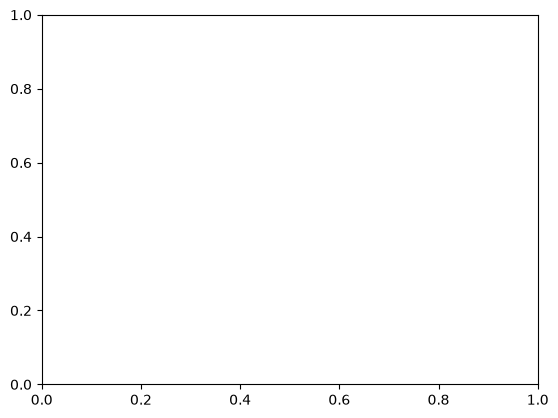

In [ ]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

fs = 128  # sampling frequency

f, t, Sxx = spectrogram(X[0], fs)

plt.imshow(10*np.log10(Sxx),
           aspect='auto',
           origin='lower',
           cmap='jet')
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()

# conv 2D

In [96]:
class EEGCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(128 * 80 * 1, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.flatten(x)

        x = self.classifier(x)

        return x

In [97]:
num_classes = len(np.unique(y))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EEGCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [98]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [111]:
y_test.squeeze(1).shape

(1492,)

In [124]:
import numpy as np

y = np.array(y).squeeze()

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [126]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [121]:
y_test.shape

(1492,)

In [128]:
# 1. split data
from torch.utils.data import DataLoader, TensorDataset
X_train, X_test, y_train, y_test =  train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# 3. add channel dim
X_train = X_train.unsqueeze(1)
X_test  = X_test.unsqueeze(1)

# 4. dataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

# 5. loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(
    X_train,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    X_test,
    batch_size=32,
    shuffle=False
)

# training loop

In [129]:
epochs = 30

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {running_loss:.4f} "
        f"Accuracy: {train_acc:.2f}%"
    )

Epoch 1/30 Loss: 143.8446 Accuracy: 59.37%
Epoch 2/30 Loss: 99.4775 Accuracy: 75.32%
Epoch 3/30 Loss: 86.0120 Accuracy: 78.86%
Epoch 4/30 Loss: 82.9557 Accuracy: 80.60%
Epoch 5/30 Loss: 77.9426 Accuracy: 81.74%
Epoch 6/30 Loss: 73.8390 Accuracy: 82.09%
Epoch 7/30 Loss: 66.3308 Accuracy: 84.29%
Epoch 8/30 Loss: 63.9489 Accuracy: 84.27%
Epoch 9/30 Loss: 61.2428 Accuracy: 86.18%


KeyboardInterrupt: 

testing loop

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

# chrononet

In [ ]:
import torch
import torch.nn as nn


class ChronoBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.conv2 = nn.Conv1d(
            in_channels, 32,
            kernel_size=2,
            stride=2,
            padding=1
        )

        self.conv4 = nn.Conv1d(
            in_channels, 32,
            kernel_size=4,
            stride=2,
            padding=2
        )

        self.conv8 = nn.Conv1d(
            in_channels, 32,
            kernel_size=8,
            stride=2,
            padding=4
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        c1 = self.relu(self.conv2(x))
        c2 = self.relu(self.conv4(x))
        c3 = self.relu(self.conv8(x))

        return torch.cat([c1, c2, c3], dim=1)


class ChronoNet(nn.Module):
    def __init__(self, n_channels):
        super().__init__()

        # Three convolution blocks
        self.block1 = ChronoBlock(n_channels)
        self.block2 = ChronoBlock(96)
        self.block3 = ChronoBlock(96)

        # GRUs
        self.gru1 = nn.GRU(
            input_size=96,
            hidden_size=32,
            batch_first=True
        )

        self.gru2 = nn.GRU(
            input_size=32,
            hidden_size=32,
            batch_first=True
        )

        self.gru3 = nn.GRU(
            input_size=64,
            hidden_size=32,
            batch_first=True
        )

        self.gru4 = nn.GRU(
            input_size=96,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Input: (batch, seq_len, channels)

        # Conv1d expects (batch, channels, seq_len)
        x = x.permute(0, 2, 1)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # GRU expects (batch, seq_len, features)
        x = x.permute(0, 2, 1)

        g1, _ = self.gru1(x)

        g2, _ = self.gru2(g1)

        g2a = torch.cat([g1, g2], dim=2)

        g3, _ = self.gru3(g2a)

        g3a = torch.cat([g1, g2, g3], dim=2)

        g4, _ = self.gru4(g3a)

        # Last timestep
        out = g4[:, -1, :]

        out = torch.sigmoid(self.fc(out))

        return out

In [ ]:
import copy
import time
import torch
import pandas as pd

MAX_COMBOS = None

all_results = []
combo_counter = 0

for n_exclude in range(2, 3):

    n_keep = 14 - n_exclude

    for excl in combinations(ALL_CHANNELS, n_exclude):

        if MAX_COMBOS is not None and combo_counter >= MAX_COMBOS:
            print(f"Reached MAX_COMBOS={MAX_COMBOS}")
            break

        my_list = [j for j in ALL_CHANNELS if j not in excl]
        label_info = make_combo_label(my_list)

        combo_counter += 1

        print(
            f"[{combo_counter:5d}] "
            f"model={MODEL_NAME} | keep={n_keep} | "
            f"{label_info['title']}"
        )

        combo_dir = os.path.join(
            OUT_ROOT,
            f"keep{n_keep:02d}",
            label_info["fname"]
        )

        os.makedirs(combo_dir, exist_ok=True)

        #########################################################
        # Prepare data
        #########################################################

        data_array = df1a[..., np.array(my_list) - 1]
        label_array = df2.iloc[:, 0].values

        X_train, X_test, y_train, y_test = train_test_split(
            data_array,
            label_array,
            test_size=TEST_SIZE,
            random_state=RANDOM_SEED,
            stratify=label_array,
        )

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train.reshape(-1, X_train.shape[-1])
        ).reshape(X_train.shape)

        X_test = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)

        train_dataset = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32),
        )

        test_dataset = TensorDataset(
            torch.tensor(X_test, dtype=torch.float32),
            torch.tensor(y_test, dtype=torch.float32),
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
        )

        #########################################################
        # Build model
        #########################################################

        reset_seeds(RANDOM_SEED)

        model = ChronoNet(n_keep).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=LR
        )

        criterion = torch.nn.BCEWithLogitsLoss()

        history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": [],
        }

        #########################################################
        # Early stopping
        #########################################################

        patience = 8
        best_acc = 0
        wait = 0
        best_weights = copy.deepcopy(model.state_dict())

        t0 = time.time()

        #########################################################
        # Training
        #########################################################

        for epoch in range(EPOCHS):

            ####################
            # Train
            ####################

            model.train()

            running_loss = 0
            correct = 0
            total = 0

            for x, y in train_loader:

                x = x.to(device)
                y = y.float().unsqueeze(1).to(device)

                optimizer.zero_grad()

                logits = model(x)

                loss = criterion(logits, y)

                loss.backward()

                optimizer.step()

                running_loss += loss.item()

                pred = (torch.sigmoid(logits) >= 0.5)

                correct += (pred == y.bool()).sum().item()
                total += y.size(0)

            train_loss = running_loss / len(train_loader)
            train_acc = correct / total

            ####################
            # Validation
            ####################

            model.eval()

            running_loss = 0
            correct = 0
            total = 0

            y_true = []
            y_prob = []

            with torch.no_grad():

                for x, y in test_loader:

                    x = x.to(device)
                    y = y.float().unsqueeze(1).to(device)

                    logits = model(x)

                    loss = criterion(logits, y)

                    running_loss += loss.item()

                    probs = torch.sigmoid(logits)

                    pred = probs >= 0.5

                    correct += (pred == y.bool()).sum().item()
                    total += y.size(0)

                    y_true.extend(y.cpu().numpy())
                    y_prob.extend(probs.cpu().numpy())

            val_loss = running_loss / len(test_loader)
            val_acc = correct / total

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            print(
                f"Epoch {epoch+1}/{EPOCHS} "
                f"Train Acc={train_acc:.4f} "
                f"Val Acc={val_acc:.4f}"
            )

            ####################
            # Early stopping
            ####################

            if val_acc > best_acc:

                best_acc = val_acc
                wait = 0
                best_weights = copy.deepcopy(model.state_dict())

            else:

                wait += 1

                if wait >= patience:
                    print("Early stopping")
                    break

        model.load_state_dict(best_weights)

        train_time = time.time() - t0

        #########################################################
        # Final prediction
        #########################################################

        model.eval()

        y_pred = []

        with torch.no_grad():

            for x, _ in test_loader:

                x = x.to(device)

                probs = torch.sigmoid(model(x))

                y_pred.extend(probs.cpu().numpy())

        y_pred = np.array(y_pred)

        #########################################################
        # Save figures
        #########################################################

        metrics = save_figures_for_combo(
            history=history,
            y_test=y_test,
            y_pred=y_pred,
            label_info=label_info,
            out_dir=combo_dir,
        )

        metrics["train_time_s"] = round(train_time, 1)

        pd.DataFrame(history).to_csv(
            os.path.join(
                combo_dir,
                f"{label_info['fname']}_history.csv"
            ),
            index=False,
        )

        all_results.append(metrics)

        print(
            f'val_acc={metrics["val_acc"]:.2f}% '
            f'AUC={metrics["auc"]:.3f} '
            f'F1={metrics["f1"]:.2f}% '
            f'κ={metrics["cohen_kappa"]:.3f}'
        )

    else:
        continue
    break

print(f"\nDone. Combinations run: {combo_counter}")